# **Part III: Neural Network Classification with PyTorch**


**Dataset:** CIFAR-10  
**Task:** Neural Network Classification  



## Goal
In this notebook, we implement and evaluate a neural network classifier for CIFAR-10 using PyTorch.  
We use the provided notebook structure, complete the required implementation, compare several model and training configurations using validation performance, and select a final model for test evaluation.

## Experimental Protocol
- We use the provided train, validation, and test split.
- We perform model and hyperparameter selection using the validation set only.
- We do not use the test set during tuning.
- We report the final test result only after selecting the best validation configuration.

**Colab Execution Note**

We adapted this notebook for direct execution in Google Colab.

Instructions:
1. Select `Runtime -> Change runtime type` and choose `GPU`.
2. Run the import and setup cells.
3. Run the CIFAR-10 data loading cell. The dataset will be downloaded automatically if needed.
4. Use the validation set for model and hyperparameter selection.
5. Evaluate on the test set only after selecting the final model.

## Notebook Structure

This notebook is organized into the following parts:

1. **Preparation and data loading**: We load the CIFAR-10 dataset and define the train, validation, and test splits.
2. **Provided PyTorch background sections**: We keep the original instructional sections on barebones PyTorch, `nn.Module`, and `nn.Sequential` as reference and supporting context.
3. **Final model development**: We implement, train, and compare several neural network configurations for the CIFAR-10 classification task.
4. **Model selection and evaluation**: We select the final model using validation performance only, and evaluate it on the test set only after model selection is complete.

This structure allows us to clearly separate the provided background material from our own experimental work and final results.

## Environment Setup

In this section, we import the required PyTorch and torchvision packages, define the computation device, and prepare the notebook for training and evaluation.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import sampler

import torchvision.datasets as dset
import torchvision.transforms as T

import numpy as np

USE_GPU = True
dtype = torch.float32 # We will be using float throughout this assignment.

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

# Constant to control how frequently we print train loss.
print_every = 100
print('using device:', device)

using device: cuda


In [3]:
import os
os.makedirs('./data', exist_ok=True)
print('Data folder is ready at ./data')


Data folder is ready at ./data


# Part I. Preparation

Now, let's load the CIFAR-10 dataset. This might take a couple of minutes the first
time you run the code, but the files should stay cached afterwards.

In earlier sections of this assignment, dataset handling was performed manually.
Here, we use PyTorch's built-in utilities to load, preprocess, and iterate over
the data in minibatches.


In [4]:
NUM_TRAIN = 49000

# The torchvision.transforms package provides tools for preprocessing data.
# Here we set up a transform that normalizes the data by subtracting the mean
# RGB value and dividing by the standard deviation of each RGB channel.
# The mean and standard deviation values are hardcoded.
transform = T.Compose([
                T.ToTensor(),
                T.Normalize((0.4914, 0.4822, 0.4465),
                            (0.2023, 0.1994, 0.2010))
            ])

# We set up a Dataset object for each split (train / val / test).
# Datasets load examples one at a time, so we wrap each Dataset in a DataLoader
# which forms minibatches. The training set is split into train and validation
# subsets using a Sampler.
cifar10_train = dset.CIFAR10('./data', train=True, download=True,
                             transform=transform)
loader_train = DataLoader(cifar10_train, batch_size=64,
                          sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN)))

cifar10_val = dset.CIFAR10('./data', train=True, download=True,
                           transform=transform)
loader_val = DataLoader(cifar10_val, batch_size=64,
                        sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN, 50000)))

cifar10_test = dset.CIFAR10('./data', train=False, download=True,
                            transform=transform)
loader_test = DataLoader(cifar10_test, batch_size=64)


100%|██████████| 170M/170M [00:04<00:00, 40.9MB/s]


## Provided Background Section: Barebones PyTorch

The following cells are part of the original notebook provided for this assignment and are kept here as background reference.

This section introduces low-level PyTorch operations, including tensor-based forward computation, automatic differentiation, and manual parameter updates. It helps build intuition for how PyTorch works internally before moving to higher-level APIs.

Our main project contribution in this notebook begins later in the model development and hyperparameter selection stages, where we implement and compare several configurations using validation-based model selection.

**Background Utility: Flatten**

The following helper function is part of the provided notebook and is used to reshape image tensors into flat vectors when working with fully connected layers. We keep it here as a small utility for the background sections and for any model component that requires flattening before a linear layer.

In [5]:
def flatten(x):
    N = x.shape[0] # read in N, C, H, W
    return x.view(N, -1)  # "flatten" the C * H * W values into a single vector per image


### Background Example: Two-Layer Fully Connected Network

The following function is part of the provided notebook and illustrates a simple fully connected neural network implemented with low-level tensor operations. We keep it here as background reference for the barebones PyTorch section.

In [6]:
import torch.nn.functional as F  # useful stateless functions

def two_layer_fc(x, params):
    """
    A fully-connected neural network; the architecture is:
    NN is fully connected -> ReLU -> fully connected layer.
    Note that this function only defines the forward pass;
    PyTorch will take care of the backward pass for us.

    The input to the network will be a minibatch of data, of shape
    (N, d1, ..., dM) where d1 * ... * dM = D. The hidden layer will have H units,
    and the output layer will produce scores for C classes.

    Inputs:
    - x: A PyTorch Tensor of shape (N, d1, ..., dM) giving a minibatch of
      input data.
    - params: A list [w1, w2] of PyTorch Tensors giving weights for the network;
      w1 has shape (D, H) and w2 has shape (H, C).

    Returns:
    - scores: A PyTorch Tensor of shape (N, C) giving classification scores for
      the input data x.
    """
    x = flatten(x)
    w1, w2 = params
    x = F.relu(x.mm(w1))
    x = x.mm(w2)
    return x

### Background Utilities: Weight Initialization

The following helper functions are part of the provided notebook and implement simple weight initialization utilities for the barebones PyTorch section. In particular, `random_weight` uses Kaiming-style scaling based on the input fan-in, while `zero_weight` creates zero-initialized tensors when needed.

In [7]:
def random_weight(shape):
    """
    Create random Tensors for weights; setting requires_grad=True means that we
    want to compute gradients for these Tensors during the backward pass.
    We use Kaiming normalization: sqrt(2 / fan_in)
    """
    if len(shape) == 2:  # FC weight
        fan_in = shape[0]
    else:
        fan_in = np.prod(shape[1:]) # general fan-in computation
    # randn is standard normal distribution generator.
    w = torch.randn(shape, device=device, dtype=dtype) * np.sqrt(2. / fan_in)
    w.requires_grad = True
    return w

def zero_weight(shape):
    return torch.zeros(shape, device=device, dtype=dtype, requires_grad=True)

### Barebones PyTorch: Check Accuracy
When training the model we will use the following function to check the accuracy of our model on the training or validation sets.

When checking accuracy we don't need to compute any gradients; as a result we don't need PyTorch to build a computational graph for us when we compute scores. To prevent a graph from being built we scope our computation under a `torch.no_grad()` context manager.

In [8]:
def check_accuracy_part2(loader, model_fn, params):
    """
    Check the accuracy of a classification model.

    Inputs:
    - loader: A DataLoader for the data split we want to check
    - model_fn: A function that performs the forward pass of the model,
      with the signature scores = model_fn(x, params)
    - params: List of PyTorch Tensors giving parameters of the model

    Returns: Nothing, but prints the accuracy of the model
    """
    split = 'val' if loader.dataset.train else 'test'
    print('Checking accuracy on the %s set' % split)
    num_correct, num_samples = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.int64)
            scores = model_fn(x, params)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f%%)' % (num_correct, num_samples, 100 * acc))

### BareBones PyTorch: Training Loop
We can now set up a basic training loop to train our network. We will train the model using stochastic gradient descent without momentum. We will use `torch.functional.cross_entropy` to compute the loss; you can [read about it here](http://pytorch.org/docs/stable/nn.html#cross-entropy).

The training loop takes as input the neural network function, a list of initialized parameters (`[w1, w2]` in our example), and learning rate.

In [9]:
def train_part2(model_fn, params, learning_rate):
    """
    Train a model on CIFAR-10.

    Inputs:
    - model_fn: A Python function that performs the forward pass of the model.
      It should have the signature scores = model_fn(x, params) where x is a
      PyTorch Tensor of image data, params is a list of PyTorch Tensors giving
      model weights, and scores is a PyTorch Tensor of shape (N, C) giving
      scores for the elements in x.
    - params: List of PyTorch Tensors giving weights for the model
    - learning_rate: Python scalar giving the learning rate to use for SGD

    Returns: Nothing
    """
    for t, (x, y) in enumerate(loader_train):
        # Move the data to the proper device (GPU or CPU)
        x = x.to(device=device, dtype=dtype)
        y = y.to(device=device, dtype=torch.long)

        # Forward pass: compute scores and loss
        scores = model_fn(x, params)
        loss = F.cross_entropy(scores, y)

        # Backward pass: PyTorch figures out which Tensors in the computational
        # graph has requires_grad=True and uses backpropagation to compute the
        # gradient of the loss with respect to these Tensors, and stores the
        # gradients in the .grad attribute of each Tensor.
        loss.backward()

        # Update parameters. We don't want to backpropagate through the
        # parameter updates, so we scope the updates under a torch.no_grad()
        # context manager to prevent a computational graph from being built.
        with torch.no_grad():
            for w in params:
                w -= learning_rate * w.grad

                # Manually zero the gradients after running the backward pass
                w.grad.zero_()

        if t % print_every == 0:
            print('Iteration %d, loss = %.4f' % (t, loss.item()))
            check_accuracy_part2(loader_val, model_fn, params)
            print()

### BareBones PyTorch: Train a Two-Layer Network
Now we are ready to run the training loop. We need to explicitly allocate tensors for the fully connected weights, `w1` and `w2`.

Each minibatch of CIFAR has 64 examples, so the tensor shape is `[64, 3, 32, 32]`.

After flattening, `x` shape should be `[64, 3 * 32 * 32]`. This will be the size of the first dimension of `w1`.
The second dimension of `w1` is the hidden layer size, which will also be the first dimension of `w2`.

Finally, the output of the network is a 10-dimensional vector that represents the probability distribution over 10 classes.

You do not need to tune any hyperparameters. After training for one epoch, you
should observe that the model learns non-trivial structure in the data.


In [10]:
hidden_layer_size = 4000
learning_rate = 1e-2

w1 = random_weight((3 * 32 * 32, hidden_layer_size))
w2 = random_weight((hidden_layer_size, 10))

train_part2(two_layer_fc, [w1, w2], learning_rate)

Iteration 0, loss = 3.3073
Checking accuracy on the val set
Got 135 / 1000 correct (13.50%)

Iteration 100, loss = 2.4890
Checking accuracy on the val set
Got 338 / 1000 correct (33.80%)

Iteration 200, loss = 2.1296
Checking accuracy on the val set
Got 401 / 1000 correct (40.10%)

Iteration 300, loss = 2.0029
Checking accuracy on the val set
Got 390 / 1000 correct (39.00%)

Iteration 400, loss = 1.7568
Checking accuracy on the val set
Got 411 / 1000 correct (41.10%)

Iteration 500, loss = 1.5097
Checking accuracy on the val set
Got 427 / 1000 correct (42.70%)

Iteration 600, loss = 1.8323
Checking accuracy on the val set
Got 430 / 1000 correct (43.00%)

Iteration 700, loss = 1.5635
Checking accuracy on the val set
Got 453 / 1000 correct (45.30%)



## PyTorch Module API

In this section, we move from low-level tensor-based implementations to the `nn.Module` interface, which provides a cleaner and more scalable way to define neural network architectures.

The following example introduces a simple fully connected network implemented with `nn.Module`. This serves as a useful transition before our main experimental section, where we design and compare stronger models for CIFAR-10.

In [11]:
class TwoLayerFC(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        # assign layer objects to class attributes
        self.fc1 = nn.Linear(input_size, hidden_size)
        # nn.init package contains convenient initialization methods
        # http://pytorch.org/docs/master/nn.html#torch-nn-init
        nn.init.kaiming_normal_(self.fc1.weight)
        self.fc2 = nn.Linear(hidden_size, num_classes)
        nn.init.kaiming_normal_(self.fc2.weight)

    def forward(self, x):
        # forward always defines connectivity
        x = flatten(x)
        scores = self.fc2(F.relu(self.fc1(x)))
        return scores



### Module API: Accuracy Evaluation

Given the validation or test set, we can evaluate the classification accuracy of a neural network.

In this version, the model parameters are managed internally by the module, so we only pass the model itself.

In [12]:
def check_accuracy_part34(loader, model):
    if loader.dataset.train:
        print('Checking accuracy on validation set')
    else:
        print('Checking accuracy on test set')
    num_correct = 0
    num_samples = 0
    model.eval()  # set model to evaluation mode
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.long)
            scores = model(x)
            _, preds = scores.max(1)
            num_correct += (preds == y).sum()
            num_samples += preds.size(0)
        acc = float(num_correct) / num_samples
        print('Got %d / %d correct (%.2f)' % (num_correct, num_samples, 100 * acc))

### Module API: Training Loop
We also use a slightly different training loop. Rather than updating the values of the weights ourselves, we use an Optimizer object from the `torch.optim` package, which abstract the notion of an optimization algorithm and provides implementations of most of the algorithms commonly used to optimize neural networks.

In [13]:
def train_part34(model, optimizer, epochs=1):
    """
    Train a model on CIFAR-10 using the PyTorch Module API.

    Inputs:
    - model: A PyTorch Module giving the model to train.
    - optimizer: An Optimizer object we will use to train the model
    - epochs: (Optional) A Python integer giving the number of epochs to train for

    Returns: Nothing, but prints model accuracies during training.
    """
    model = model.to(device=device)  # move the model parameters to CPU/GPU
    for e in range(epochs):
        for t, (x, y) in enumerate(loader_train):
            model.train()  # put model to training mode
            x = x.to(device=device, dtype=dtype)  # move to device, e.g. GPU
            y = y.to(device=device, dtype=torch.long)

            scores = model(x)
            loss = F.cross_entropy(scores, y)

            # Zero out all of the gradients for the variables which the optimizer
            # will update.
            optimizer.zero_grad()

            # This is the backwards pass: compute the gradient of the loss with
            # respect to each  parameter of the model.
            loss.backward()

            # Actually update the parameters of the model using the gradients
            # computed by the backwards pass.
            optimizer.step()

            if t % print_every == 0:
                print('Iteration %d, loss = %.4f' % (t, loss.item()))
                check_accuracy_part34(loader_val, model)
                print()

### Module API: Train a Two-Layer Network
Now we are ready to run the training loop. In contrast to part II, we don't explicitly allocate parameter tensors anymore.

Simply pass the input size, hidden layer size, and number of classes (i.e. output size) to the constructor of `TwoLayerFC`.

You also need to define an optimizer that tracks all the learnable parameters inside `TwoLayerFC`.

You do not need to tune any hyperparameters. After training for one epoch, you
should observe that the model learns non-trivial structure in the data.


In [14]:
hidden_layer_size = 4000
learning_rate = 1e-2
model = TwoLayerFC(3 * 32 * 32, hidden_layer_size, 10)
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

train_part34(model, optimizer)

Iteration 0, loss = 3.2004
Checking accuracy on validation set
Got 167 / 1000 correct (16.70)

Iteration 100, loss = 2.2568
Checking accuracy on validation set
Got 373 / 1000 correct (37.30)

Iteration 200, loss = 2.0586
Checking accuracy on validation set
Got 351 / 1000 correct (35.10)

Iteration 300, loss = 2.0229
Checking accuracy on validation set
Got 398 / 1000 correct (39.80)

Iteration 400, loss = 2.4448
Checking accuracy on validation set
Got 405 / 1000 correct (40.50)

Iteration 500, loss = 1.4366
Checking accuracy on validation set
Got 402 / 1000 correct (40.20)

Iteration 600, loss = 1.6454
Checking accuracy on validation set
Got 459 / 1000 correct (45.90)

Iteration 700, loss = 1.9602
Checking accuracy on validation set
Got 444 / 1000 correct (44.40)



## PyTorch Sequential API

In this section, we present the `nn.Sequential` interface, which provides a compact way to define feed-forward neural networks.

The following example rewrites the previous fully connected network using `nn.Sequential`. This serves as an additional background example before our main experimental section.

In [15]:
# We need to wrap `flatten` function in a module in order to stack it
# in nn.Sequential
class Flatten(nn.Module):
    def forward(self, x):
        return flatten(x)

hidden_layer_size = 4000
learning_rate = 1e-2

model = nn.Sequential(
    Flatten(),
    nn.Linear(3 * 32 * 32, hidden_layer_size),
    nn.ReLU(),
    nn.Linear(hidden_layer_size, 10),
)

# you can use Nesterov momentum in optim.SGD
optimizer = optim.SGD(model.parameters(), lr=learning_rate,
                     momentum=0.9, nesterov=True)

train_part34(model, optimizer)

Iteration 0, loss = 2.3023
Checking accuracy on validation set
Got 137 / 1000 correct (13.70)

Iteration 100, loss = 1.9630
Checking accuracy on validation set
Got 358 / 1000 correct (35.80)

Iteration 200, loss = 1.7403
Checking accuracy on validation set
Got 415 / 1000 correct (41.50)

Iteration 300, loss = 1.7523
Checking accuracy on validation set
Got 439 / 1000 correct (43.90)

Iteration 400, loss = 1.7303
Checking accuracy on validation set
Got 402 / 1000 correct (40.20)

Iteration 500, loss = 1.7875
Checking accuracy on validation set
Got 455 / 1000 correct (45.50)

Iteration 600, loss = 1.7648
Checking accuracy on validation set
Got 437 / 1000 correct (43.70)

Iteration 700, loss = 1.7146
Checking accuracy on validation set
Got 444 / 1000 correct (44.40)



# **Main Experimental Section: CIFAR-10 Model Development**

In this section, we perform the main experimental work of this notebook.

We compare several neural network configurations for CIFAR-10, select hyperparameters using validation performance only, and keep the test set untouched until the final evaluation.

Our goals in this section are:
1. Compare several model architectures and training configurations.
2. Select the best configuration using validation accuracy.
3. Keep the test set for final evaluation only.
4. Summarize what we learned from the comparisons.

### Experiment Utilities

In this section, we define helper functions for validation-based model evaluation and experiment tracking. These utilities will be used in the following experiments to compare different model configurations and select the best one based on validation performance.

In [16]:
import copy
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def evaluate_model(model, loader):
    model.eval()
    total_correct = 0
    total_samples = 0
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=torch.long)

            scores = model(x)
            loss = F.cross_entropy(scores, y)

            total_loss += loss.item() * x.size(0)
            preds = scores.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total_samples += y.size(0)

    return total_loss / total_samples, total_correct / total_samples


def run_experiment(model, optimizer, epochs=10, model_name="model"):
    model = model.to(device=device)

    history = {
        "model_name": model_name,
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = -1.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_samples = 0

        for x, y in loader_train:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=torch.long)

            optimizer.zero_grad()
            scores = model(x)
            loss = F.cross_entropy(scores, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            running_samples += y.size(0)

        train_loss = running_loss / running_samples
        val_loss, val_acc = evaluate_model(model, loader_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, history

### First Comparison Round

In this section, we run a first comparison round between several neural network configurations.

We compare different architectural and optimization choices using validation performance only. At this stage, we do not evaluate on the test set.

In [17]:
class FCBaseline(nn.Module):
    def __init__(self, hidden_size=512):
        super().__init__()
        self.net = nn.Sequential(
            Flatten(),
            nn.Linear(3 * 32 * 32, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 10)
        )

    def forward(self, x):
        return self.net(x)


class FCRegularized(nn.Module):
    def __init__(self, hidden1=1024, hidden2=512, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            Flatten(),
            nn.Linear(3 * 32 * 32, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 10)
        )

    def forward(self, x):
        return self.net(x)


class SimpleCNN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


experiment_configs = [
    {
        "name": "fc_baseline_sgd",
        "model": FCBaseline(hidden_size=512),
        "optimizer": lambda model: optim.SGD(model.parameters(), lr=1e-2)
    },
    {
        "name": "fc_regularized_adam",
        "model": FCRegularized(hidden1=1024, hidden2=512, dropout=0.3),
        "optimizer": lambda model: optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    },
    {
        "name": "simple_cnn_adam",
        "model": SimpleCNN(dropout=0.3),
        "optimizer": lambda model: optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    }
]

all_histories = []
best_model = None
best_history = None
best_name = None
best_val_acc = -1.0

### First Experimental Comparison

We now run the first comparison round between the selected model configurations.  
At this stage, model selection is based only on validation performance, and the test set remains untouched.

In [18]:
results_summary = []

for config in experiment_configs:
    print("=" * 80)
    print(f"Running experiment: {config['name']}")

    current_model = config["model"]
    current_optimizer = config["optimizer"](current_model)

    trained_model, history = run_experiment(
        current_model,
        current_optimizer,
        epochs=10,
        model_name=config["name"]
    )

    current_best_val_acc = max(history["val_acc"])
    current_best_val_loss = min(history["val_loss"])

    history["best_val_acc"] = current_best_val_acc
    history["best_val_loss"] = current_best_val_loss

    all_histories.append(history)

    results_summary.append({
        "name": config["name"],
        "best_val_acc": current_best_val_acc,
        "best_val_loss": current_best_val_loss
    })

    print(
        f"Finished {config['name']} | "
        f"best_val_acc={current_best_val_acc:.4f} | "
        f"best_val_loss={current_best_val_loss:.4f}"
    )

    if current_best_val_acc > best_val_acc:
        best_val_acc = current_best_val_acc
        best_model = trained_model
        best_history = history
        best_name = config["name"]

print("\n" + "=" * 80)
print("Validation summary:")
for result in results_summary:
    print(
        f"{result['name']}: "
        f"best_val_acc={result['best_val_acc']:.4f}, "
        f"best_val_loss={result['best_val_loss']:.4f}"
    )

print("\nBest model selected by validation accuracy:")
print(f"{best_name} with best_val_acc={best_val_acc:.4f}")

Running experiment: fc_baseline_sgd
Epoch 1/10 | train_loss=1.7047 | val_loss=1.5800 | val_acc=0.4690
Epoch 2/10 | train_loss=1.5086 | val_loss=1.4818 | val_acc=0.4680
Epoch 3/10 | train_loss=1.4166 | val_loss=1.4432 | val_acc=0.4920
Epoch 4/10 | train_loss=1.3476 | val_loss=1.4198 | val_acc=0.5060
Epoch 5/10 | train_loss=1.2896 | val_loss=1.3830 | val_acc=0.5070
Epoch 6/10 | train_loss=1.2384 | val_loss=1.3555 | val_acc=0.5250
Epoch 7/10 | train_loss=1.1918 | val_loss=1.3468 | val_acc=0.5270
Epoch 8/10 | train_loss=1.1477 | val_loss=1.3221 | val_acc=0.5340
Epoch 9/10 | train_loss=1.1066 | val_loss=1.3613 | val_acc=0.5380
Epoch 10/10 | train_loss=1.0676 | val_loss=1.3285 | val_acc=0.5300
Finished fc_baseline_sgd | best_val_acc=0.5380 | best_val_loss=1.3221
Running experiment: fc_regularized_adam
Epoch 1/10 | train_loss=1.6775 | val_loss=1.4570 | val_acc=0.4670
Epoch 2/10 | train_loss=1.5047 | val_loss=1.3994 | val_acc=0.4870
Epoch 3/10 | train_loss=1.4384 | val_loss=1.3355 | val_acc=0.

### Visual Comparison of the First Round

We now visualize the first comparison round using training loss, validation loss, and validation accuracy curves.  
These plots help us compare convergence behavior, generalization, and overall validation performance across the candidate models.

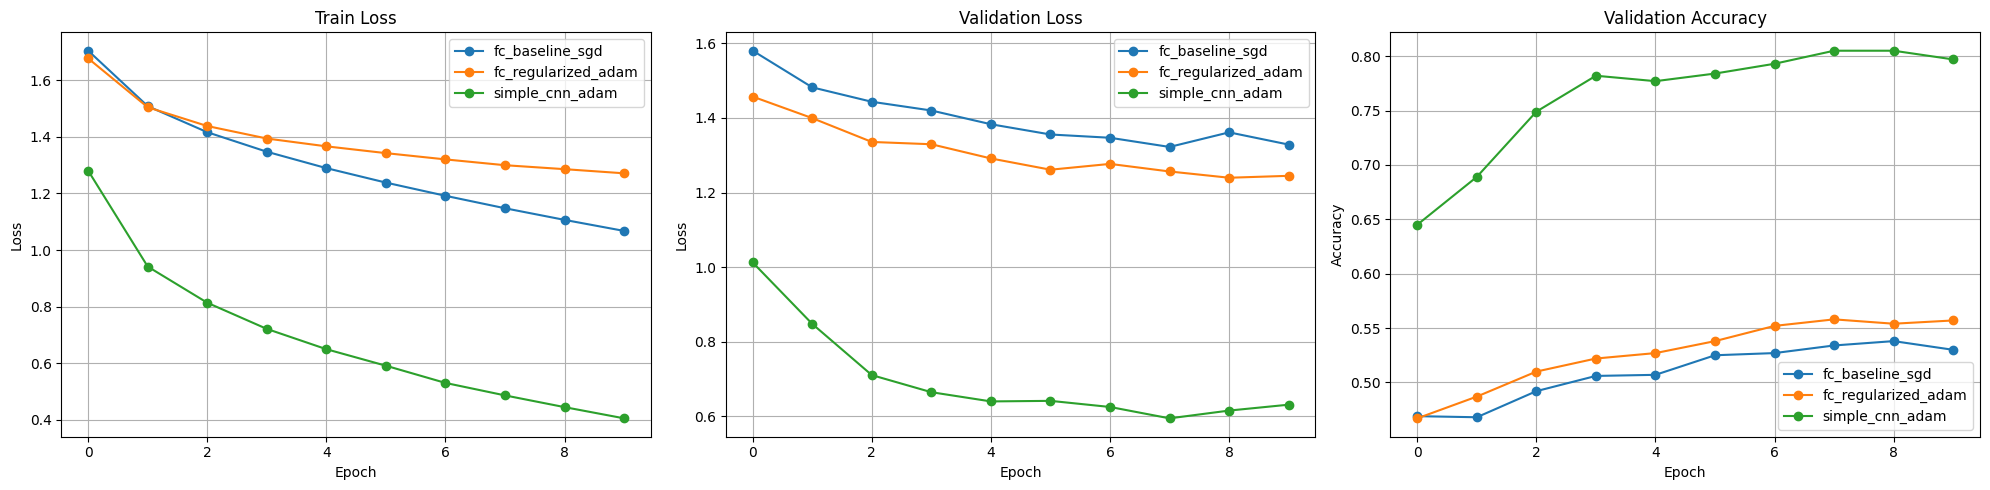

In [19]:
import matplotlib.pyplot as plt

assert "all_histories" in globals(), "all_histories is not defined. Please run the first-round experiment cell first."

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

metrics = ["train_loss", "val_loss", "val_acc"]
titles = ["Train Loss", "Validation Loss", "Validation Accuracy"]
ylabels = ["Loss", "Loss", "Accuracy"]

for ax, metric, title, ylabel in zip(axes, metrics, titles, ylabels):
    for history in all_histories:
        ax.plot(history[metric], marker='o', label=history["model_name"])
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

### Interpretation of the First Comparison Round

The plots show a clear advantage for the convolutional model over the fully connected alternatives.

The two fully connected models improve gradually, but their validation accuracy remains limited, reaching only about 0.54 to 0.56. In contrast, the CNN reaches validation accuracy above 0.80 and achieves much lower validation loss.

This result is consistent with the structure of the CIFAR-10 dataset. Fully connected models ignore the spatial structure of images after flattening, while the CNN preserves local spatial information through convolution and pooling operations.

We also observe that the CNN validation loss reaches its minimum before the final epoch and slightly increases afterward, which suggests mild overfitting near the end of training. This motivates a more focused second comparison round within the CNN family.

### Refined CNN Search

After identifying the CNN family as the strongest direction in the first comparison round, we now perform a more focused search within this family.

In this stage, we compare several CNN configurations by varying optimization and regularization choices, while continuing to use validation accuracy as the selection criterion.

In [20]:
def make_loaders(batch_size):
    train_loader = DataLoader(
        cifar10_train,
        batch_size=batch_size,
        sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN))
    )
    val_loader = DataLoader(
        cifar10_val,
        batch_size=batch_size,
        sampler=sampler.SubsetRandomSampler(range(NUM_TRAIN, 50000))
    )
    return train_loader, val_loader


def run_experiment_with_loaders(model, optimizer, train_loader, val_loader, epochs=10, model_name="model"):
    model = model.to(device=device)

    history = {
        "model_name": model_name,
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = -1.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_samples = 0

        for x, y in train_loader:
            x = x.to(device=device, dtype=dtype)
            y = y.to(device=device, dtype=torch.long)

            optimizer.zero_grad()
            scores = model(x)
            loss = F.cross_entropy(scores, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            running_samples += y.size(0)

        train_loss = running_loss / running_samples
        val_loss, val_acc = evaluate_model(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return model, history

In [21]:
cnn_configs = [
    {"name": "cnn_lr1e3_do03_wd1e4_bs64",  "lr": 1e-3, "dropout": 0.3, "weight_decay": 1e-4, "batch_size": 64},
    {"name": "cnn_lr5e4_do03_wd1e4_bs64",  "lr": 5e-4, "dropout": 0.3, "weight_decay": 1e-4, "batch_size": 64},
    {"name": "cnn_lr1e3_do05_wd1e4_bs64",  "lr": 1e-3, "dropout": 0.5, "weight_decay": 1e-4, "batch_size": 64},
    {"name": "cnn_lr1e3_do03_wd5e4_bs64",  "lr": 1e-3, "dropout": 0.3, "weight_decay": 5e-4, "batch_size": 64},
    {"name": "cnn_lr1e3_do03_wd1e4_bs128", "lr": 1e-3, "dropout": 0.3, "weight_decay": 1e-4, "batch_size": 128},
]

cnn_histories = []
cnn_results_summary = []

best_cnn_model = None
best_cnn_history = None
best_cnn_name = None
best_cnn_val_acc = -1.0

### Second Comparison Round: Focused CNN Search

After identifying the convolutional architecture as the strongest direction in the first comparison round, we now perform a more focused search within the CNN family.

In this stage, we compare several CNN configurations by varying learning rate, dropout, weight decay, and batch size. Model selection continues to rely on validation accuracy only, while the test set remains untouched.

In [22]:
for cfg in cnn_configs:
    print("=" * 80)
    print(f"Running CNN config: {cfg['name']}")

    train_loader_cfg, val_loader_cfg = make_loaders(cfg["batch_size"])
    model_cfg = SimpleCNN(dropout=cfg["dropout"])
    optimizer_cfg = optim.Adam(
        model_cfg.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    trained_model, history = run_experiment_with_loaders(
        model_cfg,
        optimizer_cfg,
        train_loader_cfg,
        val_loader_cfg,
        epochs=10,
        model_name=cfg["name"]
    )

    current_best_val_acc = max(history["val_acc"])
    current_best_val_loss = min(history["val_loss"])

    history["best_val_acc"] = current_best_val_acc
    history["best_val_loss"] = current_best_val_loss
    cnn_histories.append(history)

    cnn_results_summary.append({
        "name": cfg["name"],
        "best_val_acc": current_best_val_acc,
        "best_val_loss": current_best_val_loss
    })

    print(
        f"Finished {cfg['name']} | "
        f"best_val_acc={current_best_val_acc:.4f} | "
        f"best_val_loss={current_best_val_loss:.4f}"
    )

    if current_best_val_acc > best_cnn_val_acc:
        best_cnn_val_acc = current_best_val_acc
        best_cnn_model = trained_model
        best_cnn_history = history
        best_cnn_name = cfg["name"]

print("\n" + "=" * 80)
print("CNN validation summary:")
for result in cnn_results_summary:
    print(
        f"{result['name']}: "
        f"best_val_acc={result['best_val_acc']:.4f}, "
        f"best_val_loss={result['best_val_loss']:.4f}"
    )

print("\nBest CNN model selected by validation accuracy:")
print(f"{best_cnn_name} with best_val_acc={best_cnn_val_acc:.4f}")

Running CNN config: cnn_lr1e3_do03_wd1e4_bs64
Epoch 1/10 | train_loss=1.2729 | val_loss=0.9982 | val_acc=0.6450
Epoch 2/10 | train_loss=0.9215 | val_loss=0.7893 | val_acc=0.7290
Epoch 3/10 | train_loss=0.7918 | val_loss=0.7273 | val_acc=0.7530
Epoch 4/10 | train_loss=0.6973 | val_loss=0.6598 | val_acc=0.7710
Epoch 5/10 | train_loss=0.6252 | val_loss=0.7012 | val_acc=0.7730
Epoch 6/10 | train_loss=0.5684 | val_loss=0.6146 | val_acc=0.7970
Epoch 7/10 | train_loss=0.5097 | val_loss=0.6376 | val_acc=0.7840
Epoch 8/10 | train_loss=0.4619 | val_loss=0.5742 | val_acc=0.8000
Epoch 9/10 | train_loss=0.4194 | val_loss=0.6377 | val_acc=0.7960
Epoch 10/10 | train_loss=0.3809 | val_loss=0.5777 | val_acc=0.8080
Finished cnn_lr1e3_do03_wd1e4_bs64 | best_val_acc=0.8080 | best_val_loss=0.5742
Running CNN config: cnn_lr5e4_do03_wd1e4_bs64
Epoch 1/10 | train_loss=1.2929 | val_loss=0.9942 | val_acc=0.6440
Epoch 2/10 | train_loss=0.9364 | val_loss=0.8538 | val_acc=0.6990
Epoch 3/10 | train_loss=0.8038 | va

### Visual Comparison of the Focused CNN Search

We now visualize the second comparison round within the CNN family.  
These plots allow us to compare the effect of learning rate, dropout, weight decay, and batch size on convergence behavior and validation performance.

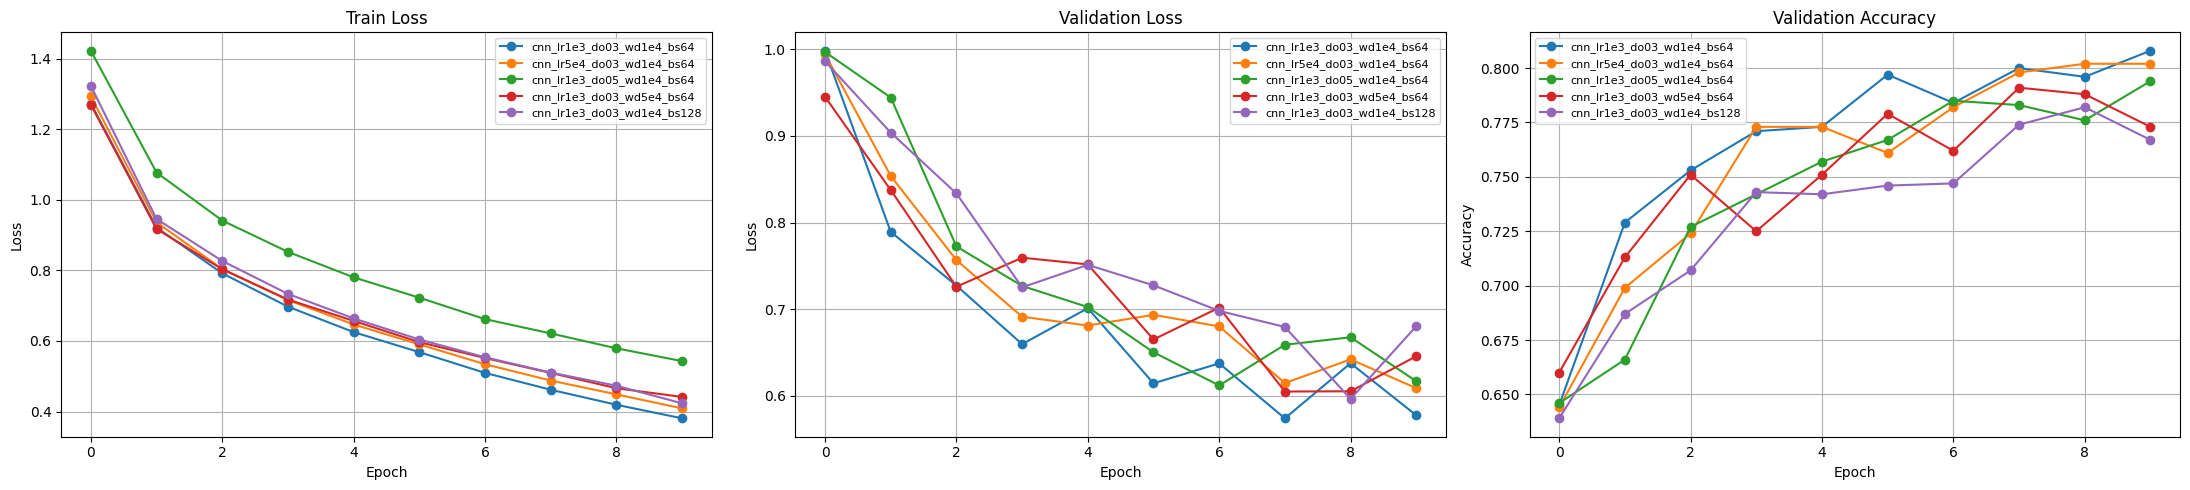

In [24]:
import matplotlib.pyplot as plt

assert "cnn_histories" in globals(), "cnn_histories is not defined. Please run the focused CNN search cell first."

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

metrics = ["train_loss", "val_loss", "val_acc"]
titles = ["Train Loss", "Validation Loss", "Validation Accuracy"]
ylabels = ["Loss", "Loss", "Accuracy"]

for ax, metric, title, ylabel in zip(axes, metrics, titles, ylabels):
    for history in cnn_histories:
        ax.plot(history[metric], marker='o', label=history["model_name"])
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Interpretation of the Focused CNN Search

The focused CNN search provides a clearer view of how the main training choices affect performance within the same architecture family.

Among the configurations we tested, the model with learning rate `1e-3`, dropout `0.3`, weight decay `1e-4`, and batch size `64` achieved the highest validation accuracy, reaching `0.8080`. Since validation accuracy was our predefined model selection criterion, we selected this configuration as the final candidate for test evaluation.

The comparison also reveals several useful trends. Reducing the learning rate to `5e-4` produced competitive results, but did not improve the best validation accuracy. Increasing dropout from `0.3` to `0.5` led to slower optimization and consistently higher training loss, suggesting that the stronger regularization made optimization harder in this setting. Increasing weight decay from `1e-4` to `5e-4` did not improve the best validation accuracy in this run. Using batch size `128` also gave reasonable results, but it slightly underperformed compared with batch size `64`.

An important observation is that several CNN variants performed similarly, with relatively small gaps between their best validation accuracies. This suggests that the model family is fairly robust, while still supporting the choice of `cnn_lr1e3_do03_wd1e4_bs64` as the final configuration according to our validation based selection rule.

Overall, the focused search shows that the original CNN configuration remained the strongest option in this experiment and provided a well supported choice for final evaluation on the held out test set.

### Final Evaluation on the Held-Out Test Set

After completing model selection using validation performance only, we now evaluate the selected configuration on the held-out test set.

This is the first and only use of the test set in this notebook.

In [25]:
assert best_cnn_model is not None, "best_cnn_model is None. Please run the CNN search cell first."

final_model = best_cnn_model
final_model_name = best_cnn_name
final_val_acc = best_cnn_val_acc

final_test_loss, final_test_acc = evaluate_model(final_model, loader_test)

print("=" * 80)
print("Final evaluation on the held-out test set")
print(f"Selected model: {final_model_name}")
print(f"Best validation accuracy used for selection: {final_val_acc:.4f}")
print(f"Test loss: {final_test_loss:.4f}")
print(f"Test accuracy: {final_test_acc:.4f} ({100 * final_test_acc:.2f}%)")

Final evaluation on the held-out test set
Selected model: cnn_lr1e3_do03_wd1e4_bs64
Best validation accuracy used for selection: 0.8080
Test loss: 0.6331
Test accuracy: 0.7963 (79.63%)


### Interpretation of the Final Test Evaluation

After selecting the final CNN configuration using validation accuracy only, we evaluated it once on the held out test set.

The selected model, `cnn_lr1e3_do03_wd1e4_bs64`, achieved a test accuracy of `0.7963`, which is close to its validation performance (`0.8080`). This relatively small gap suggests that the selected model generalizes reasonably well and that the validation based selection procedure was reliable.

Overall, the final test result supports the conclusion that the CNN architecture substantially outperforms the fully connected alternatives on CIFAR-10 in this notebook, while also showing stable generalization from validation to test.